## Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Load Dataset

In [2]:
train_data = pd.read_pickle('../data/preprocess/train_data.pkl')
test_data = pd.read_pickle('../data/preprocess/test_data.pkl')

In [3]:
train_data.head(2)

,age,gender,bmi,bloodpressure,diabetic,children,smoker,claim,age_group,bmi_category,bp_status,reg_northwest,reg_southeast,reg_southwest
1148,32.0,1,26.7,115,1,1,1,26109.33,2,2,0,1,0,0
807,51.0,0,25.7,83,1,0,0,11454.02,3,2,0,1,0,0


In [4]:
test_data.head(2)

,age,gender,bmi,bloodpressure,diabetic,children,smoker,claim,age_group,bmi_category,bp_status,reg_northwest,reg_southeast,reg_southwest
394,29.0,0,40.2,85,1,0,0,5400.98,2,3,0,0,1,0
881,36.0,1,26.8,88,1,1,0,12609.89,3,2,0,1,0,0


## Prepare Data

In [5]:
X_train = train_data.drop('claim', axis=1)
y_train = train_data['claim']

X_test = test_data.drop('claim', axis=1)
y_test = test_data['claim']

In [6]:
X_train.shape, y_train.shape

((1072, 13), (1072,))

## Modeling

We will use XGBoost & Random Forest and find out which algorithm is best.

Why this algorithm? Because it is robust to outliers.

Note abaout the result:

---RandomForest---
- MAE: 4,001.87
- RMSE: 5,396.61
- R2: 0.82

---XGBoost---
- MAE: 4,142.93
- RMSE: 5,629.61
- R2: 0.81

In [7]:
# Why do we use random_state? Because this algorithm relies on randomization to prevent overfitting.
# Therefore, we want to ensure that the model's results are reproducible even if we run the code again.
models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
} 

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

# ascending=True -> because we want sort by MAE from lowest to hightest
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='MAE', ascending=True).reset_index(drop=True)
df_results_styled = df_results.style.format({
    'MAE': '{:,.2f}',
    'RMSE': '{:,.2f}',
    'R2': '{:,.2f}'
}) 
display(df_results_styled)

,Model,MAE,RMSE,R2
0,RandomForest,"4,001.87","5,396.61",0.82
1,XGBoost,"4,142.93","5,629.61",0.81


## Cross Validation
Check the models with cross validation to ensure the MAE score is not due to chance data distribution.

>Note for Analysis

Random Forest shows more stable performance than XGBoost with a lower MAE and smaller Std.

In [8]:
results_cv = []

for name, model in models.items():
    # calculate the MAE cv with neg_mean_absolute_error because the default cv will return the highest score
    # multiply by -1 to return a positive value
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    mae_mean = -cv_scores.mean() 
    mae_std = cv_scores.std()
    
    results_cv.append({
        'Model': name,
        'CV_MAE_mean': mae_mean,
        'CV_MAE_std': mae_std
    })

df_cv = pd.DataFrame(results_cv).sort_values('CV_MAE_mean')
display(df_cv.style.format({
    'CV_MAE_mean': '{:,.2f}',
    'CV_MAE_std': '{:,.2f}'
}))

,Model,CV_MAE_mean,CV_MAE_std
0,RandomForest,"4,123.33",147.14
1,XGBoost,"4,439.46",170.61


## Check Importance Feature

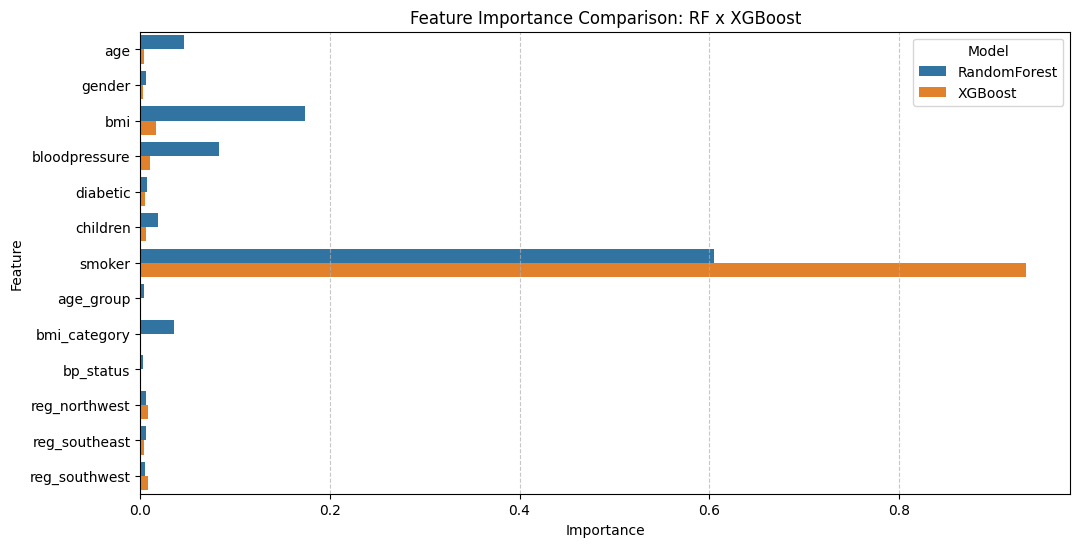

In [9]:
importance_feature = []

for name, model in models.items():
    importance = model.feature_importances_
    
    feature_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importance,
        'Model': name
    }) 
    importance_feature.append(feature_df)

all_importance_feat = pd.concat(importance_feature)

plt.figure(figsize=(12, 6))
sns.barplot(data=all_importance_feat, x='Importance', y='Feature', hue='Model')
plt.title('Feature Importance Comparison: RF x XGBoost')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [10]:
df_importance_pivot = all_importance_feat.pivot(index='Feature', columns='Model', values='Importance')
# get new column for menentukan urutan feature
# why need? because we want to sort the importance feature from all models, so we avoid bias to one model
df_importance_pivot['Average'] = df_importance_pivot.mean(axis=1)
df_top_feat = df_importance_pivot.sort_values(by='Average', ascending=False).head(10)
df_top_feat_styled = df_top_feat.style.format('{:.2f}') 
display(df_top_feat_styled)
        

Model,RandomForest,XGBoost,Average
Feature,,,
smoker,0.61,0.93,0.77
bmi,0.17,0.02,0.10
bloodpressure,0.08,0.01,0.05
age,0.05,0.00,0.03
bmi_category,0.04,0.00,0.02
children,0.02,0.01,0.01
reg_northwest,0.01,0.01,0.01
reg_southwest,0.01,0.01,0.01
diabetic,0.01,0.00,0.01


## Used Shap

To see how a feature affects the results

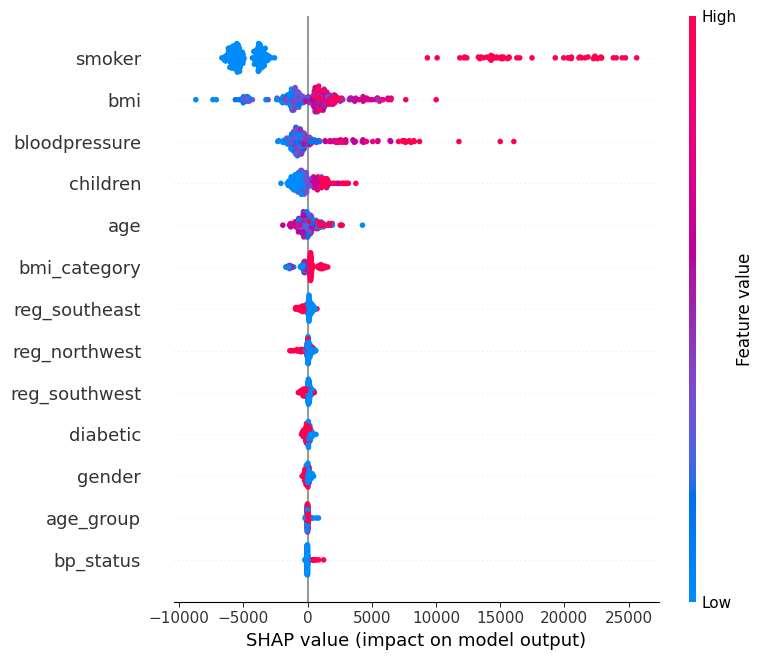

In [11]:
explainer_rf = shap.TreeExplainer(models['RandomForest'])
shap_values_rf = explainer_rf.shap_values(X_test)
shap.summary_plot(shap_values_rf, X_test)

>### Note Analysis about Importance Feature

The model has very strong predictive power for lifestyle variables (Smoker & BMI). 
However, the Residual Plot shows a consistent error pattern in the mid-claim range (10k-20k), 
indicating the need for model parameter optimization or the addition of interaction features in the next stage.